<a href="https://colab.research.google.com/github/ruforavishnu/Project_Simulations/blob/main/12th_Standard_Maths_Chapter8_Application_of_Integrals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem:



### Two startup companies operate under identical working conditions.

The first company uses 10 laptops, each running for 10 hours per day,
from Monday to Friday.

The second company uses 10 desktop PCs for the same duration.

Over the course of a month, which company is expected to incur a higher electricity bill?




In [1]:
import sympy as sp


t = sp.symbols('t',  real=True)


P_laptop = 50 + 10*sp.sin(0.5 * t)
P_desktop = 200 + 10*sp.sin(0.5  * t)


print('Laptop power function: ', P_laptop)
print('Desktop power function: ', P_desktop)




Laptop power function:  10*sin(0.5*t) + 50
Desktop power function:  10*sin(0.5*t) + 200


In [2]:
# Lets integrate power so we get energy functions

E_laptop = sp.integrate(P_laptop,  t)
E_desktop = sp.integrate(P_desktop, t)


print('Energy (laptop) :', E_laptop)
print('Energy (desktop) :', E_desktop)




Energy (laptop) : 50*t - 20.0*cos(0.5*t)
Energy (desktop) : 200*t - 20.0*cos(0.5*t)


**Ok, now lets calculate how much energy is consumed in 10hours work per day**

In [3]:
E_laptop_10h = sp.integrate(P_laptop,       (t, 0, 10)     )
E_desktop_10h = sp.integrate(P_desktop,    (t, 0, 10)    )


print("Laptop (10 hours) :",   float(E_laptop_10h),   "Watt-hours")
print('Desktop (10 hours) : ', float(E_desktop_10h),   'Watt-hours')




Laptop (10 hours) : 514.3267562907355 Watt-hours
Desktop (10 hours) :  2014.3267562907354 Watt-hours


**Right, so now we need to calculate how much electricity bill for 10 devices**

In [4]:
devices = 10


days = 22


total_laptop = E_laptop_10h *  devices * days

total_desktop = E_desktop_10h   * devices * days



print('Total Laptop Energy (Wh) :',   float(total_laptop))
print('Total Desktop Energy (Wh)  :',   float(total_desktop))




Total Laptop Energy (Wh) : 113151.8863839618
Total Desktop Energy (Wh)  : 443151.88638396177


**Now lets convert to kwh**

In [5]:
laptop_kwh = total_laptop / 1000

desktop_kwh = total_desktop / 1000




print('Laptop Energy (kwh) : ',   float(laptop_kwh))
print('Desktop Energy (kwh)  : ', float(desktop_kwh))




Laptop Energy (kwh) :  113.1518863839618
Desktop Energy (kwh)  :  443.15188638396177


**Fine, now lets plot it**

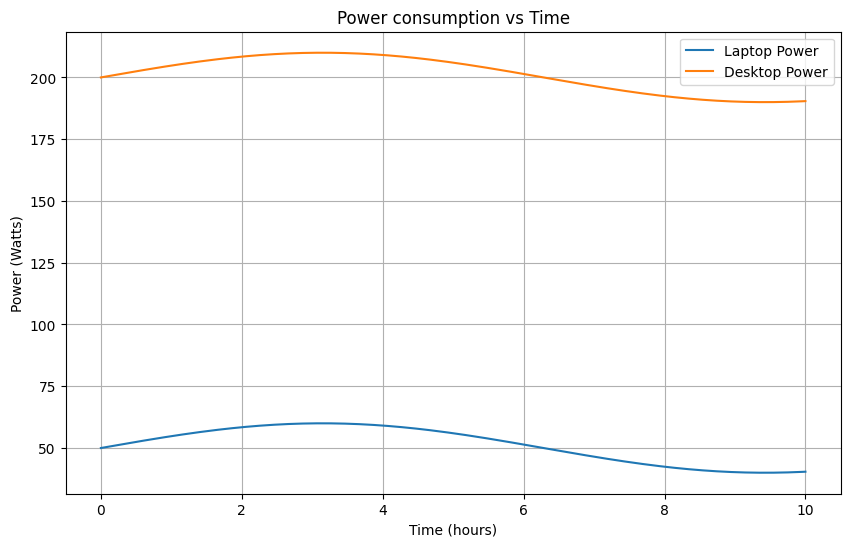

In [6]:
import numpy as np
import matplotlib.pyplot as plt


P_l_func = sp.lambdify(t,   P_laptop, 'numpy')
P_d_func = sp.lambdify(t ,   P_desktop,   'numpy')


t_vals = np.linspace(0,  10,   200)

plt.figure(figsize=(10,6))
plt.plot(t_vals,    P_l_func(t_vals),    label='Laptop Power')
plt.plot(t_vals,    P_d_func(t_vals),    label='Desktop Power')


plt.title('Power consumption vs Time')
plt.xlabel('Time (hours)')
plt.ylabel('Power (Watts)')

plt.legend()
plt.grid()
plt.show()

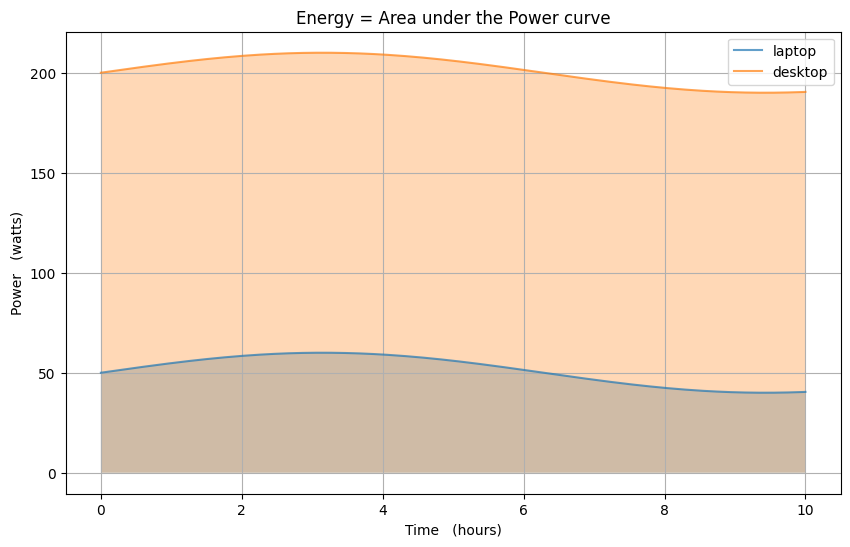

In [7]:
plt.figure(figsize=(10,6))

plt.plot(t_vals,    P_l_func(t_vals),    label='laptop',   alpha=0.7)
plt.plot(t_vals,    P_d_func(t_vals),   label='desktop',  alpha=0.7)


plt.fill_between(t_vals,   P_l_func(t_vals),    alpha=0.3)
plt.fill_between(t_vals,   P_d_func(t_vals),   alpha=0.3)


plt.title('Energy = Area under the Power curve')
plt.xlabel('Time   (hours)')
plt.ylabel('Power   (watts)')

plt.legend()
plt.grid()


plt.show()

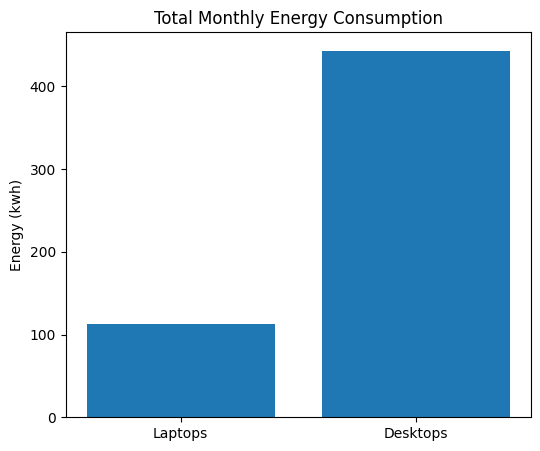

In [8]:
labels = ['Laptops', 'Desktops']
values = [float(laptop_kwh),    float(desktop_kwh)  ]


plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.title('Total Monthly Energy Consumption')
plt.ylabel('Energy (kwh)')


plt.show()

**Conclusion:**
So obviously the startup company using laptops have way lesser electricity bill than the other

